### Consigna Problema 1-Automátas Celulares 1D

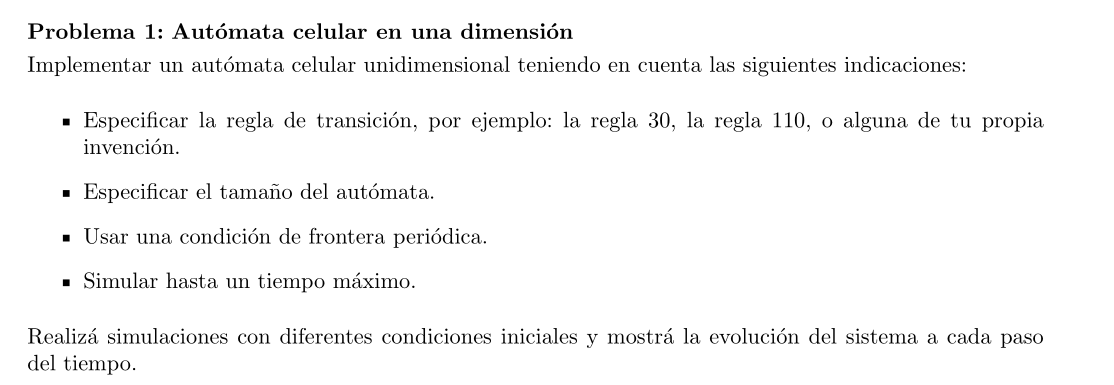

**Resumen reglas 30 y 110**

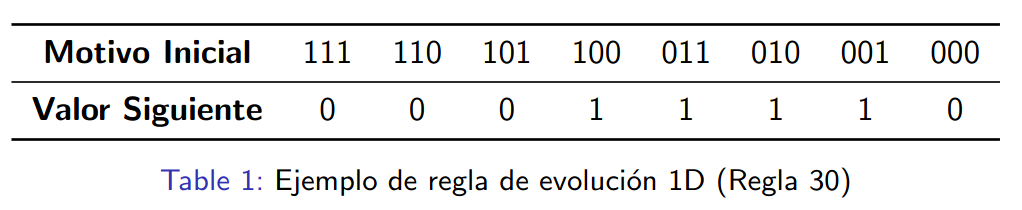

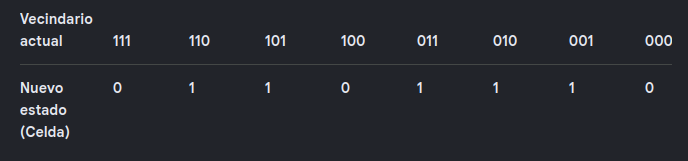

### Resolución

In [2]:
# Import librerías
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Función creo array de len = N + 1, para colocar un 1 en el centro
def array_N(N, mid = True):
    #N = 50
    array = np.zeros(N+1, dtype=int)

    if mid == True:
        array[int(N/2+1)] = 1
        
    return array

# Función con reglas de decisión 30
def dec_rules_30(window):
    
    if window == '111' or window == '110' or window == '101' or window == '000':
        return 0
    else:
        return 1

# Función con reglas de decisión 110
def dec_rules_110(window):
    
    if window == '111' or window == '100' or window == '000':
        return 0
    else:
        return 1

# Función run AC 1D
def auto_cel_1d(n, gen, rules):
    
    if rules == 30:
        dec_rules = dec_rules_30
    else:
        dec_rules = dec_rules_110
    
    # --
    array = array_N(n)
    
    # --
    array_gens_total = []

    # --
    for g in range(gen):

        list_gen = []

        for i, c in enumerate(array):
            
            #print(i, c)
            if i == 0:
                window = f'{array[-1]}{array[i]}{array[i+1]}'
                list_gen.append(dec_rules(window))
            elif i == n:
                window = f'{array[i-1]}{array[i]}{array[0]}'
                list_gen.append(dec_rules(window))
            else:
                window = f'{array[i-1]}{array[i]}{array[i+1]}'
                list_gen.append(dec_rules(window))
                
        # --
        array_gens_total.append(list_gen)
        
        #--
        array = np.array(list_gen)
    
    return np.array(array_gens_total)

(np.float64(-0.5), np.float64(100.5), np.float64(119.5), np.float64(-0.5))

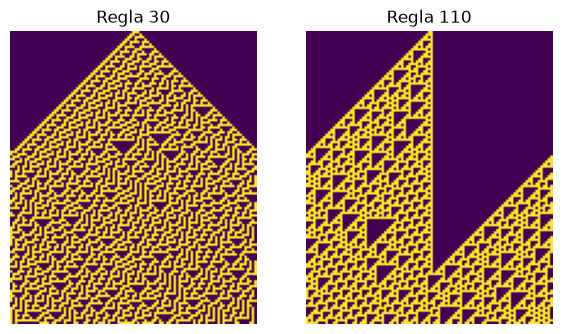

In [6]:
# Defino condiciones iniciales
n = 100 # columns (N+1)
gen = 120 # rows


# Ploteo según reglas 30 y 110
fig, ax = plt.subplots(1, 2, figsize=(7, 7))

ax[0].imshow(auto_cel_1d(n, gen, rules = 30), cmap='viridis')
ax[1].imshow(auto_cel_1d(n, gen, rules = 110), cmap='viridis')

ax[0].set_title('Regla 30')
ax[0].axis('off')

ax[1].set_title('Regla 110')
ax[1].axis('off')

#axes[0].set_title('Random Matrix')